# Financial Inclusion in Africa — Starter Notebook
### Miva Open University Hackathon

**Objective:** Build a machine learning model to predict which individuals are most likely to have or use a bank account.

**Target variable:** `bank_account` — `1` = Has a bank account, `0` = Does not

**Evaluation metric:** Accuracy

---

### Notebook Roadmap
1. Import Libraries
2. Load the Data
3. Explore the Data (EDA)
4. Preprocess the Data
5. Train a Model
6. Evaluate the Model
7. Generate Submission File

> TIP: Work through each section carefully and read all the comments. They are there to guide you!

## Step 1: Import Libraries

We import all the Python libraries we need up front. Think of libraries as toolboxes:
- `pandas` — working with tabular data (like Excel, but in Python)
- `numpy` — numerical computations
- `matplotlib` / `seaborn` — charts and visualisations
- `sklearn` — machine learning algorithms and evaluation tools

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Charts appear inline inside the notebook
%matplotlib inline
sns.set(style='whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Data

We have three CSV files:

| File | Description |
|------|-------------|
| `Train.csv` | Data WITH known labels. Used to train your model. |
| `Test.csv` | Data WITHOUT labels. You must predict these. |
| `SampleSubmission.csv` | Shows the exact format your answers must be in. |

Make sure all 3 files are in the same folder as this notebook.

In [ ]:
# pd.read_csv() reads a CSV file into a DataFrame (a table in Python)
train = pd.read_csv('Train.csv')
test  = pd.read_csv('Test.csv')
sample_submission = pd.read_csv('SampleSubmission.csv')

# .shape returns (number of rows, number of columns)
print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')

Train shape: (23524, 13)
Test shape:  (10086, 12)


In [ ]:
# .head() shows the first 5 rows — great for a quick look at the data
train.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [ ]:
# Notice the test data has NO 'bank_account' column!
# That is exactly what we need to predict.
test.head()

,country,year,uniqueid,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_6056,Urban,Yes,3,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government
1,Kenya,2018,uniqueid_6060,Urban,Yes,7,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private
2,Kenya,2018,uniqueid_6065,Rural,No,3,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent
3,Kenya,2018,uniqueid_6072,Rural,No,6,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent
4,Kenya,2018,uniqueid_6073,Urban,No,3,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent


## Step 3: Exploratory Data Analysis (EDA)

Before building a model, understand your data first. EDA helps you answer:
- How many people have a bank account vs. do not?
- Are there any missing values?
- What patterns exist in the features?

> The better you understand your data, the better your model will be!

In [ ]:
# .info() gives column names, data types, and non-null counts
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


In [ ]:
# Check for missing values — columns with many nulls need special handling
print('Missing values per column:')
print(train.isnull().sum())

Missing values per column:
country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64


In [ ]:
# How balanced is our target variable?
# If one class is much larger, we have a 'class imbalance' problem — important to know!
print('Bank account distribution:')
print(train['bank_account'].value_counts())
print()
print('As percentages:')
print(train['bank_account'].value_counts(normalize=True) * 100)

Bank account distribution:
bank_account
No     20212
Yes     3312
Name: count, dtype: int64

As percentages:
bank_account
No     85.920762
Yes    14.079238
Name: proportion, dtype: float64


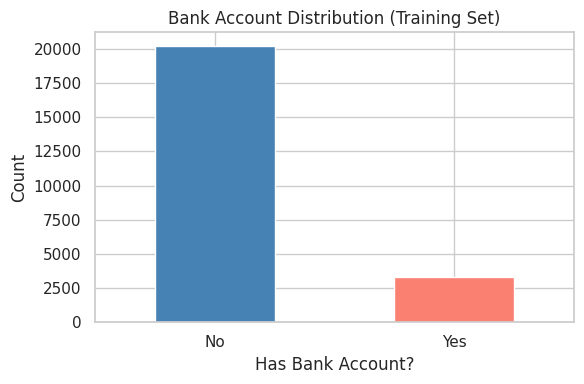

In [ ]:
# Visualise class balance
plt.figure(figsize=(6, 4))
train['bank_account'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Bank Account Distribution (Training Set)')
plt.xlabel('Has Bank Account?')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

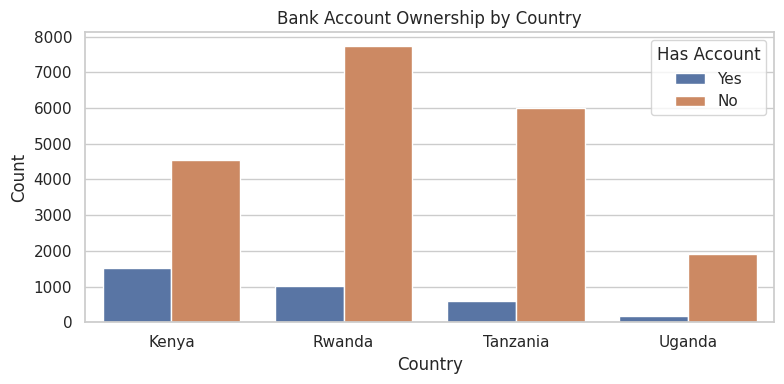

In [ ]:
# Bank account ownership by country
plt.figure(figsize=(8, 4))
sns.countplot(data=train, x='country', hue='bank_account')
plt.title('Bank Account Ownership by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend(title='Has Account')
plt.tight_layout()
plt.show()

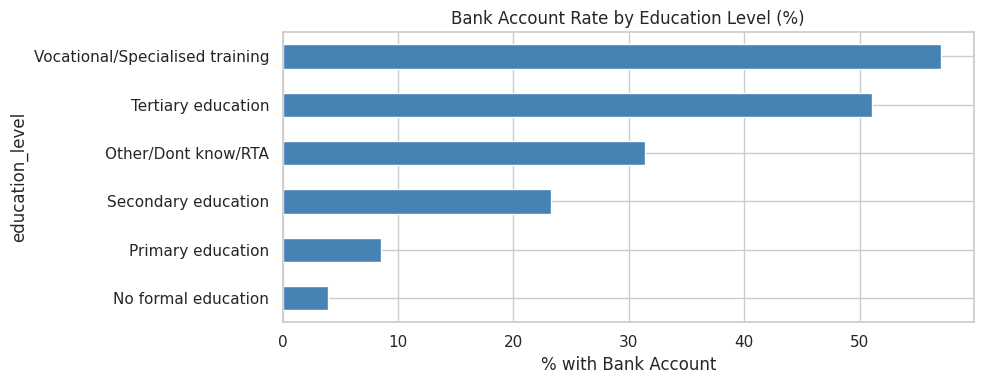

In [ ]:
# Does education level affect bank account ownership?
# We calculate the percentage with a bank account for each education level
edu_rate = train.groupby('education_level')['bank_account'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values()

plt.figure(figsize=(10, 4))
edu_rate.plot(kind='barh', color='steelblue')
plt.title('Bank Account Rate by Education Level (%)')
plt.xlabel('% with Bank Account')
plt.tight_layout()
plt.show()
# Question: Does higher education link to higher bank account ownership?

## Step 4: Preprocess the Data

Machine learning models only understand **numbers**, not text. We need to:
1. Encode the target variable: `Yes/No` → `1/0`
2. Encode categorical (text) columns → numbers
3. Handle any missing values

We also need to be careful to apply the SAME transformation to both train and test data.

In [ ]:
# Step 4a: Encode the target variable
# map() replaces specific values: 'Yes' -> 1, 'No' -> 0
train['bank_account'] = train['bank_account'].map({'Yes': 1, 'No': 0})

print('Target variable after encoding:')
print(train['bank_account'].value_counts())

Target variable after encoding:
bank_account
0    20212
1     3312
Name: count, dtype: int64


In [ ]:
# Step 4b: Define feature columns (the inputs to our model)
# We exclude 'uniqueid' (just an ID, no predictive value)
# and 'bank_account' (that's the target, not an input!)
feature_cols = [
    'country',
    'year',
    'location_type',
    'cellphone_access',
    'household_size',
    'age_of_respondent',
    'gender_of_respondent',
    'relationship_with_head',
    'marital_status',
    'education_level',
    'job_type'
]

print(f'Using {len(feature_cols)} features to train the model.')

Using 11 features to train the model.


In [ ]:
# Step 4c: Combine train and test before encoding
# This ensures categories in test are handled the same way as in train
train['is_train'] = 1
test['is_train'] = 0
test['bank_account'] = np.nan  # placeholder — we will predict this

combined = pd.concat([train, test], axis=0, ignore_index=True)
print(f'Combined dataset shape: {combined.shape}')

Combined dataset shape: (33610, 14)


In [ ]:
# Step 4d: Label encode all text columns
# LabelEncoder turns each unique string into a unique integer
# e.g. 'Rural' -> 0, 'Urban' -> 1
categorical_cols = combined[feature_cols].select_dtypes(include='object').columns.tolist()
print('Columns to encode:', categorical_cols)

le = LabelEncoder()
for col in categorical_cols:
    # Fill missing values first so the encoder does not fail
    combined[col] = combined[col].fillna('Unknown')
    combined[col] = le.fit_transform(combined[col])

print('Encoding complete!')

Columns to encode: ['country', 'location_type', 'cellphone_access', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']
Encoding complete!


In [ ]:
# Step 4e: Split back into train and test
train_enc = combined[combined['is_train'] == 1].copy()
test_enc  = combined[combined['is_train'] == 0].copy()

# X = features (the inputs), y = target (the answer we want to predict)
X = train_enc[feature_cols]
y = train_enc['bank_account'].astype(int)

# Test features (no labels — we will predict these)
X_test_final = test_enc[feature_cols]

print(f'X (train features):   {X.shape}')
print(f'y (train labels):     {y.shape}')
print(f'X_test_final:         {X_test_final.shape}')

X (train features):   (23524, 11)
y (train labels):     (23524,)
X_test_final:         (10086, 11)


## Step 5: Train a Machine Learning Model

We will use a **Random Forest Classifier** — one of the most reliable algorithms for tabular data.

**How it works (simplified):**
- The algorithm builds many decision trees (like yes/no flowcharts)
- Each tree is trained slightly differently
- To make a prediction, every tree votes, and the majority vote wins
- More trees = more reliable predictions (up to a point)

We split our labelled data into 80% training and 20% validation before fitting the model.
This lets us measure performance on data the model has never seen before.

In [ ]:
# Split training data: 80% for learning, 20% for local evaluation
# random_state=42 makes the split reproducible (same result every time you run this)
# stratify=y ensures both splits have the same proportion of 0s and 1s
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training samples:   {X_train.shape[0]}')
print(f'Validation samples: {X_val.shape[0]}')

Training samples:   18819
Validation samples: 4705


In [ ]:
# Create the Random Forest model
model = RandomForestClassifier(
    n_estimators=100,  # Number of trees in the forest
    max_depth=10,      # Limit tree depth to prevent overfitting
    random_state=42    # For reproducibility
)

# .fit() is where the actual learning happens!
# The model finds patterns that link the features to the target.
model.fit(X_train, y_train)

print('Model training complete!')

Model training complete!


## Step 6: Evaluate the Model

We check how well our model performs on the validation set — data it has never seen before.

Key metrics:
- **Accuracy** = % of all predictions that were correct
- **Precision** = Of all cases we predicted as positive, how many actually were?
- **Recall** = Of all actual positives, how many did we correctly identify?

> WARNING: This accuracy is on your local validation set. Your actual leaderboard score may differ slightly.

In [ ]:
# Make predictions on the validation set
y_pred = model.predict(X_val)

# Calculate accuracy
acc = accuracy_score(y_val, y_pred)
print(f'Validation Accuracy: {acc:.4f}  ({acc * 100:.2f}%)')
print()
print('Full Classification Report:')
print(classification_report(y_val, y_pred, target_names=['No Account (0)', 'Has Account (1)']))

Validation Accuracy: 0.8884  (88.84%)

Full Classification Report:
                 precision    recall  f1-score   support

 No Account (0)       0.90      0.98      0.94      4043
Has Account (1)       0.74      0.32      0.44       662

       accuracy                           0.89      4705
      macro avg       0.82      0.65      0.69      4705
   weighted avg       0.88      0.89      0.87      4705



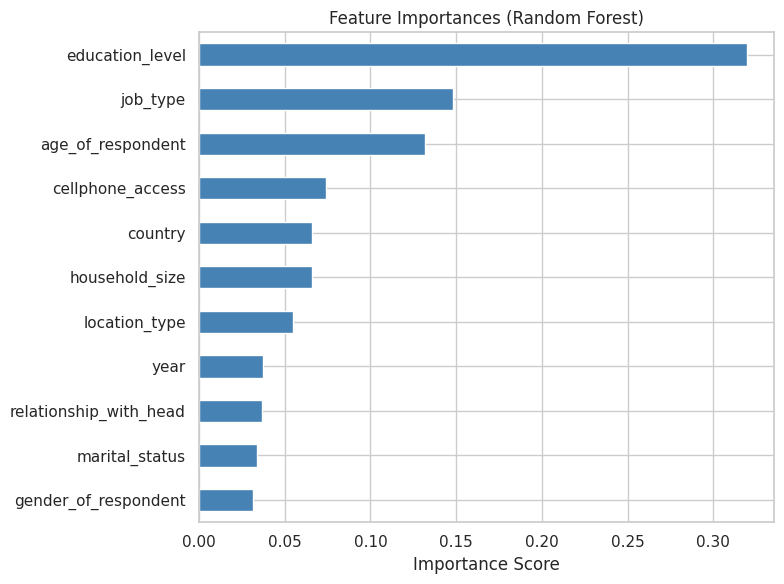

In [ ]:
# Feature Importance — which inputs did the model rely on most?
# Higher bar = more influence on the model's decisions
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Question: Which features are most important? Does that make intuitive sense to you?

## Step 7: Generate the Submission File

Now we use our trained model to predict on the actual test set and create the submission.

Required format:
```
unique_id,bank_account
uniqueid_1 x Kenya,1
uniqueid_2 x Kenya,0
```

The `unique_id` must be: `uniqueid_X x CountryName`

In [ ]:
# Predict on the unseen test set
test_predictions = model.predict(X_test_final)

print(f'Total predictions made: {len(test_predictions)}')
print(f'Predicted with bank account (1): {test_predictions.sum()}')
print(f'Predicted no bank account  (0): {(test_predictions == 0).sum()}')

Total predictions made: 10086
Predicted with bank account (1): 563
Predicted no bank account  (0): 9523


In [ ]:
# Build the unique_id column in the required format
# We use the original (non-encoded) test data for this
test_copy = test.copy()
test_copy['unique_id'] = test_copy['uniqueid'] + ' x ' + test_copy['country']

# Assemble the submission DataFrame
submission = pd.DataFrame({
    'unique_id': test_copy['unique_id'].values,
    'bank_account': test_predictions
})

print('Preview of submission:')
submission.head(10)

Preview of submission:


,unique_id,bank_account
0,uniqueid_6056 x Kenya,1
1,uniqueid_6060 x Kenya,1
2,uniqueid_6065 x Kenya,0
3,uniqueid_6072 x Kenya,0
4,uniqueid_6073 x Kenya,0
5,uniqueid_6074 x Kenya,0
6,uniqueid_6075 x Kenya,0
7,uniqueid_6076 x Kenya,0
8,uniqueid_6077 x Kenya,0
9,uniqueid_6078 x Kenya,1


In [ ]:
# Save to CSV — this is the file you will submit!
submission.to_csv('my_submission.csv', index=False)

print('Submission saved as: my_submission.csv')
print(f'Total rows: {len(submission)}')

Submission saved as: my_submission.csv
Total rows: 10086


---
## How to Improve Your Score

This notebook is a starting point. Here are ideas to push your accuracy higher:

**Feature Engineering**
- Create new features from existing ones (e.g., group ages into buckets, combine features)
- Try `pd.get_dummies()` for one-hot encoding instead of label encoding

**Try Different Models**
- `LogisticRegression` — a simple, interpretable baseline worth understanding
- `GradientBoostingClassifier` — often beats Random Forest
- `XGBClassifier` (XGBoost) — very popular in data science competitions
- `LGBMClassifier` (LightGBM) — fast and high-performing

**Tune Hyperparameters**
- Use `GridSearchCV` or `RandomizedSearchCV` to find the best settings for your model

**Handle Class Imbalance**
- Try setting `class_weight='balanced'` in the model constructor
- Explore oversampling with SMOTE from the `imbalanced-learn` library

**Better Validation**
- Use k-fold cross-validation for a more robust estimate of true accuracy

---

> **Good luck, Miva students!** The best models come from deeply understanding the problem and the data, not just running code. Think, explore, and iterate!
>
> Questions? Email: chinonso@miva.university